# 00 — Why light probes exist

**The question this whole series answers:** a game needs to know how much light
arrives at a surface point, from every direction, tens of millions of times per
frame. That is an integral over a sphere per pixel. We cannot afford it. So what
do we store instead, and how little can we get away with?

The answer that shipped in essentially every engine since ~2003 is: **nine numbers
per colour channel.** This notebook shows you the problem and the payoff. The
remaining eight notebooks explain why nine is the right number.

---

### What you need to know going in

Vectors, dot products, integrals, and the idea of an orthonormal basis. Complex
numbers and Fourier series get rebuilt from scratch in notebook 02 — you do not
need them yet.

### The convention warning, once

This series uses the **math convention: +Z is up**, `theta` measured down from
`+Z`, `phi` in the XY plane. Every formula you look up in a paper is written this
way. Most engines are Y-up. `shlib.to_gamedir` / `from_gamedir` convert at the
boundary, and notebook 07 covers what handedness does to your coefficients.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import shlib as sh
import shplot as sp

sp.use_style()
np.set_printoptions(precision=4, suppress=True, linewidth=110)

## 1. The thing we actually need

For a matte (Lambertian) surface, the light leaving a point depends on the
**irradiance** $E$ — the total light arriving, weighted by how obliquely it hits:

$$E(\mathbf{n}) \;=\; \int_{\Omega} L(\boldsymbol\omega)\,\max(0,\ \mathbf{n}\cdot\boldsymbol\omega)\;d\boldsymbol\omega$$

- $L(\boldsymbol\omega)$ — incoming radiance from direction $\boldsymbol\omega$ (the environment)
- $\mathbf{n}$ — the surface normal
- $\max(0, \mathbf{n}\cdot\boldsymbol\omega)$ — the cosine term; light at a grazing angle
  spreads over more surface, light from behind contributes nothing

Then the outgoing colour is $\;\rho/\pi \cdot E(\mathbf{n})\;$ for albedo $\rho$.

That integral is over the **whole sphere**, and it has to be evaluated for every
shaded pixel, whose normal $\mathbf{n}$ is different every time. Let's price it.

In [2]:
import shscene as ss

scene = ss.default_scene(env=ss.sky_studio)
W, H = 320, 220

# Brute force: Monte Carlo the integral above, per pixel.
import time
for spp in (16, 64, 256):
    t0 = time.perf_counter()
    img = ss.render(scene, W, H,
                    lambda p, n, a: ss.shade_ground_truth(scene, p, n, a,
                                                          spp=spp, occlusion=False))
    dt = time.perf_counter() - t0
    print(f"{spp:4d} samples/pixel   {dt:6.2f} s   "
          f"({W*H*spp/1e6:.1f}M environment lookups)")

  16 samples/pixel     0.33 s   (1.1M environment lookups)
  64 samples/pixel     0.49 s   (4.5M environment lookups)
 256 samples/pixel     1.81 s   (18.0M environment lookups)


Numpy is not a GPU, so the absolute times don't mean much — the **scaling** does.
Cost is `pixels x samples`, and you need hundreds of samples before the noise
stops being objectionable. At 1080p and 256 spp that is 530M environment lookups
**per frame**. A game has ~16 ms total.

So: precompute. But precompute *what*?

## 2. The idea: sample lighting sparsely in space, densely in angle

Lighting varies **fast with direction** (the sun is in one specific place) but
**slowly with position** (walk a metre; the sky looks basically the same).

That asymmetry is the whole trick. Put a handful of **probes** around the level.
At each one, capture the full spherical lighting function once, offline. At
runtime, look up the nearby probes, blend, and evaluate. Cost per pixel becomes a
few dozen ALU ops and no rays at all.

The only remaining question is the storage format. Here are the candidates:

In [3]:
rows = [
    # name,                          floats,  what it can represent
    ("Full HDR cubemap 32x32",       6*32*32*3, "everything, per-probe"),
    ("Irradiance cubemap 16x16",     6*16*16*3, "diffuse only, still huge"),
    ("Single ambient colour (L0)",   3,         "flat -- no direction at all"),
    ("Hemisphere / sky+ground",      6,         "up vs down only"),
    ("Ambient cube (HL2 basis)",     6*3,       "6 axis-aligned lobes"),
    ("Spherical harmonics L1",       4*3,       "constant + linear gradient"),
    ("Spherical harmonics L2",       9*3,       "+ quadratic -- the standard"),
    ("Spherical harmonics L4",       25*3,      "overkill for diffuse"),
]
print(f"{'representation':<32}{'floats':>8}{'bytes(fp16)':>13}   notes")
print("-" * 92)
for name, n, note in rows:
    print(f"{name:<32}{n:>8}{n*2:>13}   {note}")

representation                    floats  bytes(fp16)   notes
--------------------------------------------------------------------------------------------
Full HDR cubemap 32x32             18432        36864   everything, per-probe
Irradiance cubemap 16x16            4608         9216   diffuse only, still huge
Single ambient colour (L0)             3            6   flat -- no direction at all
Hemisphere / sky+ground                6           12   up vs down only
Ambient cube (HL2 basis)              18           36   6 axis-aligned lobes
Spherical harmonics L1                12           24   constant + linear gradient
Spherical harmonics L2                27           54   + quadratic -- the standard
Spherical harmonics L4                75          150   overkill for diffuse


A 32x32 HDR cubemap is 12 KB per probe. A level with 5,000 probes would be 60 MB
of lighting data, and sampling one per pixel means a cubemap fetch plus filtering
in the inner loop.

**SH L2 is 27 floats — 54 bytes.** Same 5,000 probes: 270 KB. That fits in a
constant buffer and evaluates in about 20 instructions.

The obvious objection: surely 27 numbers cannot represent an environment? And
that's correct — **it cannot.** But it does not have to. It only has to represent
the environment *after* the cosine convolution, and that turns out to be a
drastically easier function. That claim is the heart of notebook 06.

## 3. The payoff, up front

Let's just look. Same scene, same camera, three shading models:

1. **Ground truth** — Monte Carlo, 1024 samples per pixel
2. **Ambient only** — one average colour, the naive compression (3 floats)
3. **SH L2 probe** — 9 coefficients per channel (27 floats)

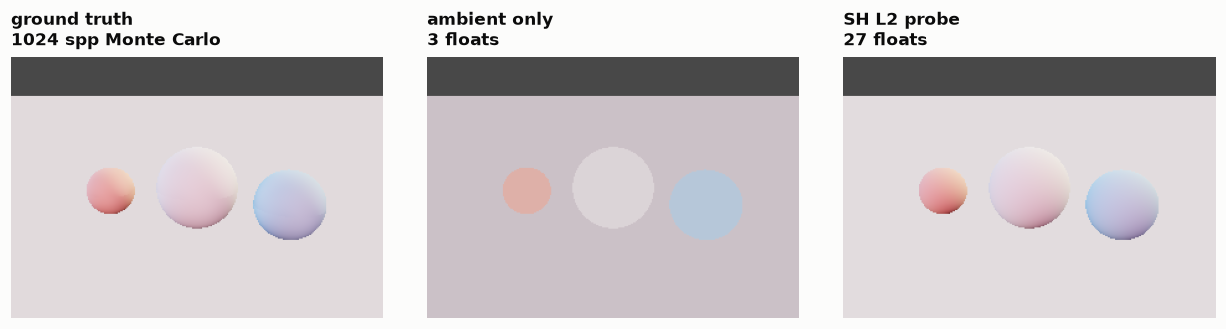

In [4]:
W, H = 300, 210
cam = ss.camera_rays(W, H)

gt = ss.render(scene, W, H, camera=cam,
               shader=lambda p, n, a: ss.shade_ground_truth(scene, p, n, a,
                                                            spp=1024, occlusion=False))

# The two compressed representations, both baked from the same environment.
c_full = sh.project_env(scene.env, 4, n_samples=200_000)
c_l0 = np.zeros_like(c_full); c_l0[0] = c_full[0]          # constant term only
c_l2 = c_full[:9]                                          # bands 0,1,2

amb = ss.render(scene, W, H, camera=cam,
                shader=lambda p, n, a: ss.shade_sh_probe(c_l0, n, a))
l2 = ss.render(scene, W, H, camera=cam,
               shader=lambda p, n, a: ss.shade_sh_probe(c_l2, n, a))

fig, axes = plt.subplots(1, 3, figsize=(11.5, 2.9))
for ax, im, t in zip(axes,
                     [gt, amb, l2],
                     ["ground truth\n1024 spp Monte Carlo",
                      "ambient only\n3 floats",
                      "SH L2 probe\n27 floats"]):
    sp.show_render(im, t, ax=ax, exposure=1.6)
fig.tight_layout()

The ambient version is flat and lifeless — it has thrown away *all* directional
information, so every surface gets the same colour regardless of which way it
faces. That is what "3 floats" buys you.

The L2 version has the warm key light on the upper right, the cool fill on the
left, the magenta rim — and the shading falls off correctly across each sphere.
For 27 floats and no rays.

Let's quantify rather than trust our eyes:

representation             relative error vs ground truth
------------------------------------------------------------
ambient (3 floats)     RMS  38.99%    max  53.06%
SH L2 (27 floats)      RMS   5.81%    max   9.45%


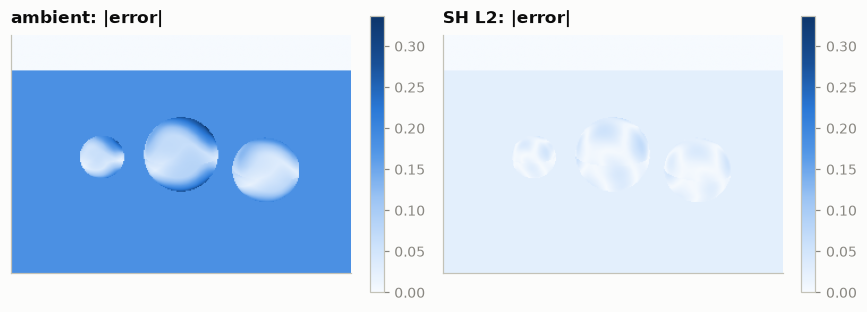

In [5]:
def report(name, approx, truth):
    err = np.abs(approx - truth)
    print(f"{name:<22} RMS {sh.relative_error(approx, truth)*100:6.2f}%    "
          f"max {err.max()/truth.max()*100:6.2f}%")

print(f"{'representation':<22} {'relative error vs ground truth':>34}")
print("-" * 60)
report("ambient (3 floats)", amb, gt)
report("SH L2 (27 floats)", l2, gt)

fig, axes = plt.subplots(1, 2, figsize=(8.0, 2.9))
for ax, im, t in zip(axes, [amb, l2], ["ambient: |error|", "SH L2: |error|"]):
    m = ax.imshow(np.abs(im - gt).mean(-1), cmap=sp.CM_SEQUENTIAL,
                  vmin=0, vmax=np.abs(amb - gt).mean(-1).max())
    ax.set_title(t); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    plt.colorbar(m, ax=ax, fraction=0.04)
fig.tight_layout()

Both error images share a colour scale, so the comparison is fair.

Note where L2's remaining error lives: on the **sharpest lighting transitions**.
That is the signature of a band-limited approximation, and it is exactly what
notebooks 05 and 06 are about.

## 4. Where this series goes

| # | Notebook | The question it answers |
|---|----------|-------------------------|
| 00 | *this one* | Why compress lighting at all? |
| 01 | Functions on a sphere | How do you integrate over directions without lying? |
| 02 | Fourier to SH | What does "frequency" mean for a function on a sphere? |
| 03 | Legendre & complex SH | Where does $Y_\ell^m$ actually come from? |
| 04 | The real SH basis | Why does graphics use a different basis than physics? |
| 05 | Projection & ringing | What breaks when you truncate, and how do you fix it? |
| 06 | **Irradiance convolution** | **Why nine coefficients is enough** |
| 07 | Rotation, storage, shaders | How does this become real HLSL/GLSL? |
| 08 | Lighting a scene | Probe grids, interpolation, and what probes *can't* do |

Notebook 06 is the one that matters. Everything before it is the vocabulary you
need to understand it; everything after is engineering.

---

**Next:** [01 — Functions on a sphere](01_functions_on_a_sphere.ipynb)